# Project 1 — Forecasting Monthly Sales or Energy Demand

Forecasting is different from ordinary supervised learning because the order of observations is meaningful. A model is not allowed to learn from future observations when it is being evaluated on the future. In this notebook, we forecast monthly demand from historical observations while respecting time order.

The dataset used here is the classic monthly airline passenger-demand series available through `seaborn` as `flights`. It is often used for teaching because trend, seasonal repetition, variance changes, and the need for time-aware validation are visually clear.

## How to read this executed notebook

This notebook is designed in two layers. The first layer teaches the forecasting ideas before the results are known. The second layer, added after execution, helps a reader interpret the visible plots and metric tables. The comments are intentionally analytical rather than procedural: they focus on whether the series shows trend, whether seasonality dominates, whether simple baselines are competitive, and whether residuals still contain structure.

When reviewing the outputs, avoid choosing a model only because it has the smallest error in one table. For a short monthly series, model ranking can change with the selected test window, the transformation used, and the forecast horizon. This is why the notebook combines a final hold-out test, rolling-origin validation, residual diagnostics, and baseline comparisons.


## Prerequisites

This notebook assumes basic familiarity with Python, pandas, NumPy, plotting, train/test split, regression metrics, and basic scikit-learn estimators. The time-series concepts are introduced from the beginning, so deep prior knowledge of forecasting is not required.

## Problem statement

Given historical monthly demand observations, predict future monthly demand while respecting temporal order. Evaluation must imitate a realistic forecasting situation: at a historical cutoff date, the model can only use observations available up to that date and must forecast the future.

In [1]:
# Optional installations if your environment does not already include these packages:
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Dataset description and source

The `flights` dataset contains monthly airline passenger counts from 1949 to 1960. Each row corresponds to one month. The target variable is the number of passengers. Although it is not a modern sales or electricity-demand dataset, it behaves like many real monthly demand series: it has a long-term trend, repeated annual seasonality, and increasing seasonal amplitude.

Because the concepts are visually clear, it is well suited for learning forecasting fundamentals before moving to noisier business or energy datasets.

In [2]:
# Load the monthly passenger-demand dataset.
# seaborn.load_dataset downloads from seaborn's public dataset repository if not cached.
try:
    flights = sns.load_dataset("flights")
except Exception:
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv"
    flights = pd.read_csv(url)

flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [3]:
# Convert the year/month columns into a true monthly DatetimeIndex.
month_to_num = {m: i for i, m in enumerate(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], start=1)}

data = flights.copy()
data["month_num"] = data["month"].astype(str).str[:3].map(month_to_num)
data["date"] = pd.to_datetime(dict(year=data["year"], month=data["month_num"], day=1))
data = data[["date", "passengers"]].set_index("date").asfreq("MS")
series = data["passengers"].astype(float)

print("Shape:", data.shape)
display(data.head())
display(data.tail())
print("Inferred frequency:", pd.infer_freq(data.index))
print("Missing values:", data.isna().sum().to_dict())

Shape: (144, 1)


,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


,passengers
date,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


Inferred frequency: MS
Missing values: {'passengers': 0}


## Initial time-series inspection

A time index is not a cosmetic detail. Forecasting models assume that observations are ordered and that spacing between observations is meaningful. If months are missing, duplicated, shuffled, or incorrectly parsed, the model may learn a distorted temporal structure.

In [4]:
expected_index = pd.date_range(data.index.min(), data.index.max(), freq="MS")
missing_dates = expected_index.difference(data.index)

print("Start:", data.index.min())
print("End:", data.index.max())
print("Number of expected monthly dates:", len(expected_index))
print("Number of missing monthly dates:", len(missing_dates))
print("Duplicates in index:", data.index.duplicated().sum())

Start: 1949-01-01 00:00:00
End: 1960-12-01 00:00:00
Number of expected monthly dates: 144
Number of missing monthly dates: 0
Duplicates in index: 0


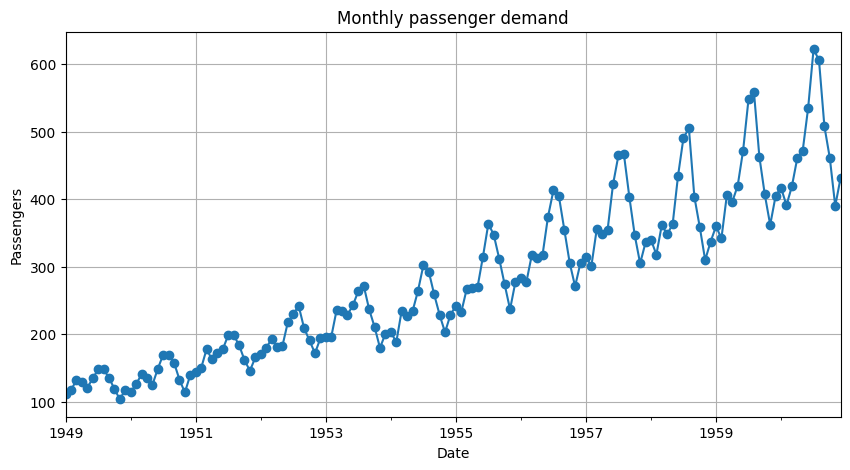

In [5]:
fig, ax = plt.subplots()
series.plot(ax=ax, marker="o")
ax.set_title("Monthly passenger demand")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
plt.show()

## Exploratory time-series analysis

A time series is often interpreted as a combination of:

- **Trend:** long-term increase or decrease.
- **Seasonality:** repeated pattern over a fixed period, such as 12 months.
- **Residual or noise:** variation not explained by trend or seasonality.

Seasonality may be **additive** or **multiplicative**. Additive seasonality means the seasonal swing is roughly constant over time. Multiplicative seasonality means the seasonal swing grows with the level of the series. After running the plots below, examine whether the seasonal amplitude stays constant or grows as demand increases.

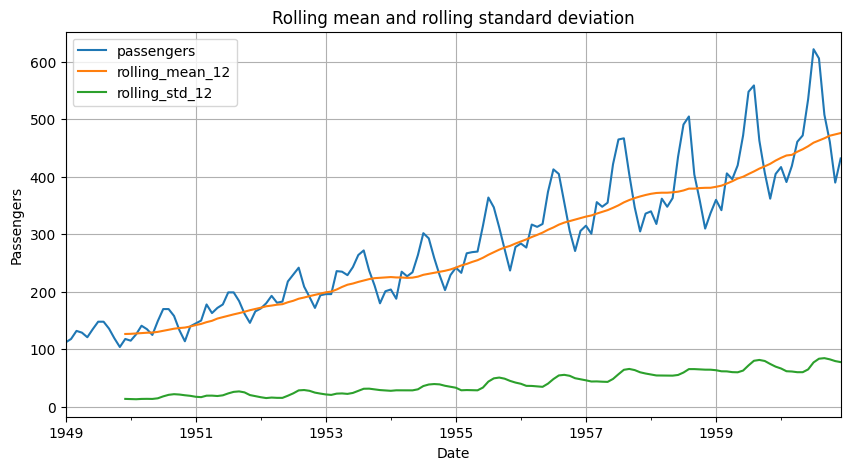

In [6]:
rolling = pd.DataFrame({
    "passengers": series,
    "rolling_mean_12": series.rolling(12).mean(),
    "rolling_std_12": series.rolling(12).std()
})

ax = rolling.plot()
ax.set_title("Rolling mean and rolling standard deviation")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
plt.show()

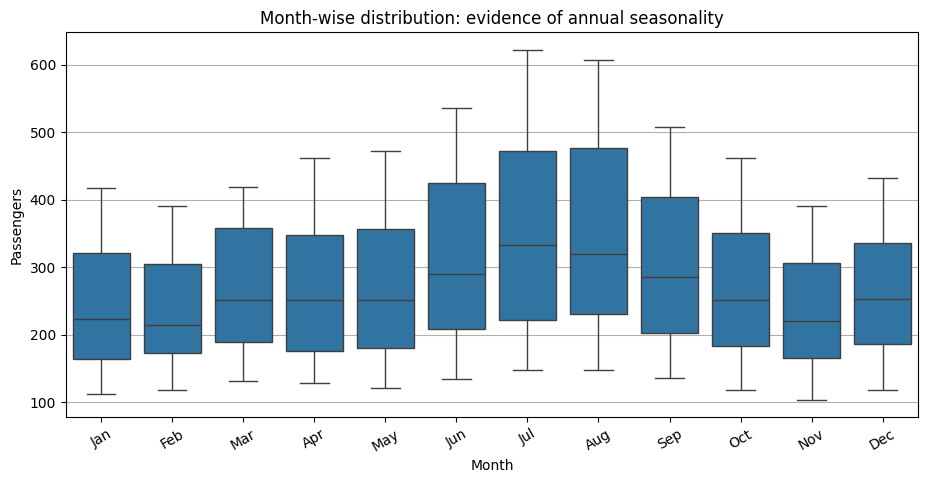

In [7]:
plot_df = data.copy()
plot_df["year"] = plot_df.index.year
plot_df["month"] = plot_df.index.month_name().str[:3]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=plot_df, x="month", y="passengers", order=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], ax=ax)
ax.set_title("Month-wise distribution: evidence of annual seasonality")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
plt.xticks(rotation=30)
plt.show()

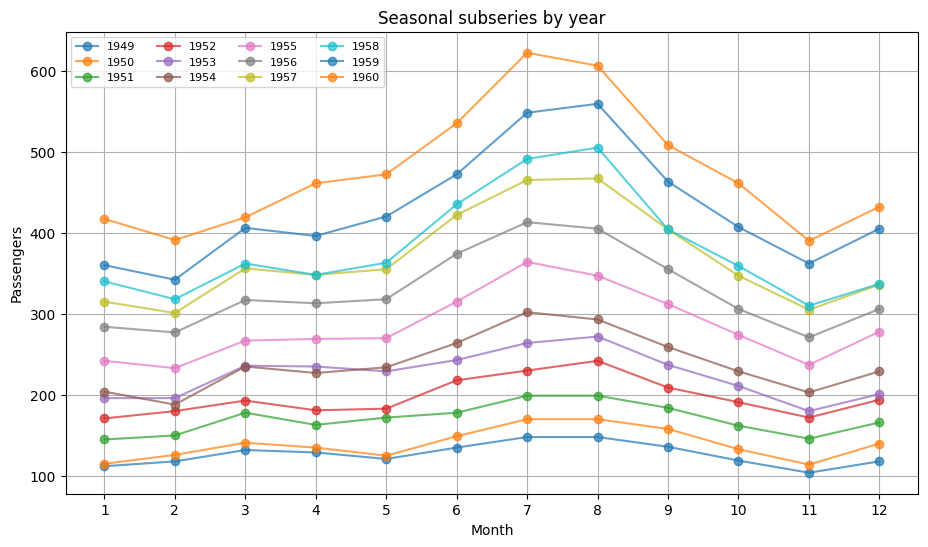

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
for year, group in plot_df.groupby("year"):
    ax.plot(group.index.month, group["passengers"], marker="o", label=str(year), alpha=0.7)

ax.set_title("Seasonal subseries by year")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.set_xticks(range(1, 13))
ax.legend(ncol=4, fontsize=8)
plt.show()

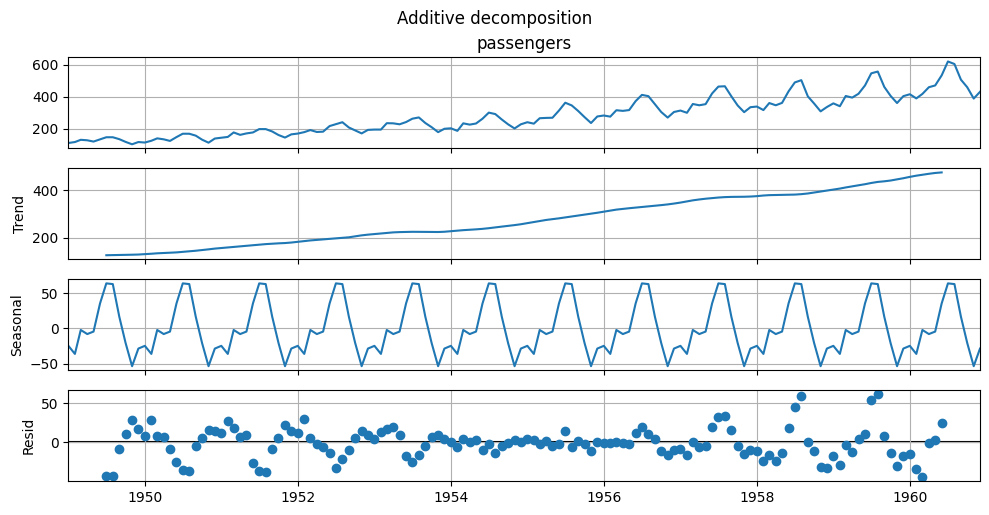

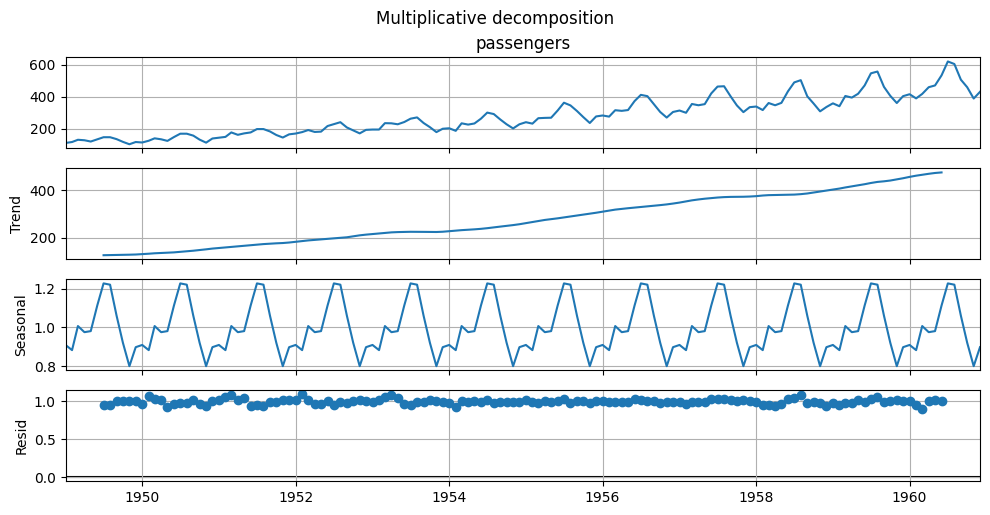

In [9]:
decomp_add = seasonal_decompose(series, model="additive", period=12)
decomp_mul = seasonal_decompose(series, model="multiplicative", period=12)

decomp_add.plot()
plt.suptitle("Additive decomposition", y=1.02)
plt.show()

decomp_mul.plot()
plt.suptitle("Multiplicative decomposition", y=1.02)
plt.show()

### seasonal amplitude and transformation choice

A visual seasonal decomposition is useful, but it can still leave a practical question: should the series be modeled on the original scale or after a log transformation? A log transform is often helpful when the absolute seasonal swing grows with the level of the series. The next diagnostic summarizes month-wise average demand and variability, then compares the original and log-transformed series.

After execution, look for two patterns. If later years show larger seasonal swings than earlier years, multiplicative seasonality or a log transformation is more defensible. If the seasonal amplitude is roughly constant, an additive seasonal model may be sufficient.


,mean,std,min,max,coefficient_of_variation
month_name,,,,,
Jan,241.750,101.033,112.0,417.0,0.418
Feb,235.000,89.619,118.0,391.0,0.381
Mar,270.167,100.559,132.0,419.0,0.372
Apr,267.083,107.375,129.0,461.0,0.402
May,271.833,114.740,121.0,472.0,0.422
Jun,311.667,134.220,135.0,535.0,0.431
Jul,351.333,156.827,148.0,622.0,0.446
Aug,351.083,155.783,148.0,606.0,0.444
Sep,302.417,123.954,136.0,508.0,0.410


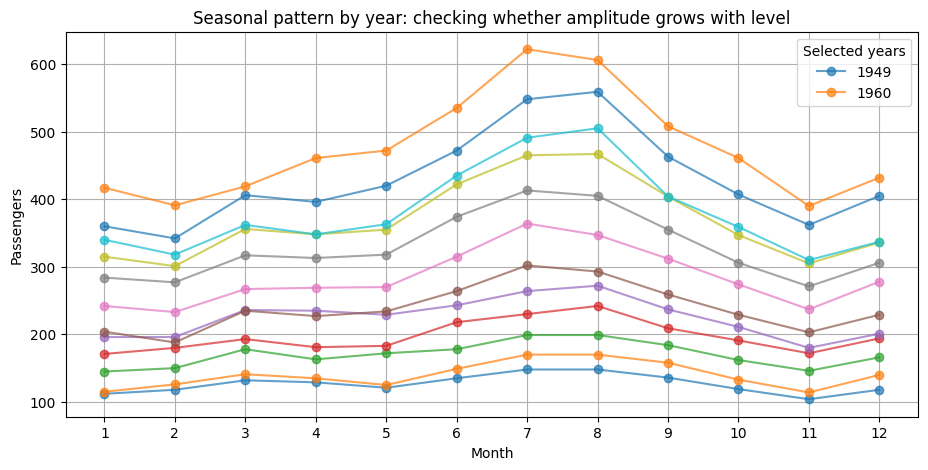

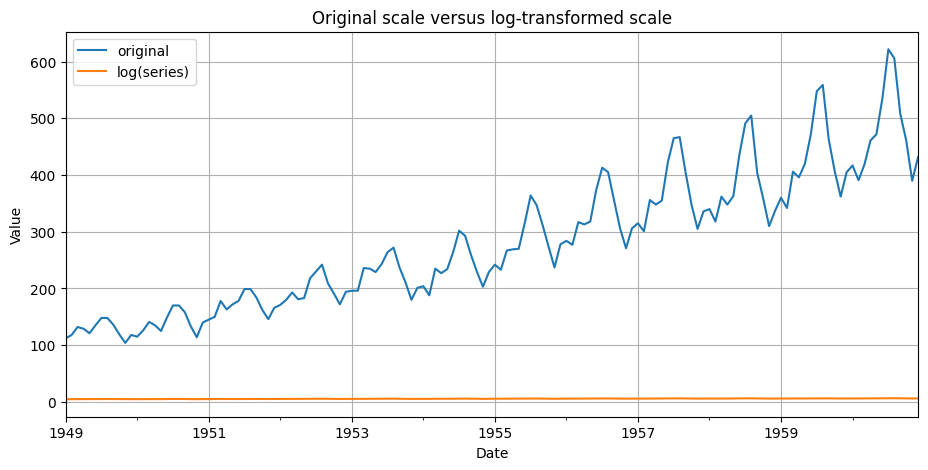

In [10]:
# Month-wise level and variability help judge additive vs multiplicative seasonality.
seasonal_strength_df = pd.DataFrame({
    "value": series,
    "year": series.index.year,
    "month": series.index.month,
    "month_name": series.index.strftime("%b")
})

monthly_profile = seasonal_strength_df.groupby("month_name", sort=False)["value"].agg(["mean", "std", "min", "max"])
monthly_profile["coefficient_of_variation"] = monthly_profile["std"] / monthly_profile["mean"]
display(monthly_profile.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
for year, group in seasonal_strength_df.groupby("year"):
    ax.plot(group["month"], group["value"], marker="o", alpha=0.7, label=str(year) if year in [series.index.year.min(), series.index.year.max()] else None)
ax.set_title("Seasonal pattern by year: checking whether amplitude grows with level")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.set_xticks(range(1, 13))
ax.legend(title="Selected years")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
series.plot(ax=ax, label="original")
np.log(series).plot(ax=ax, label="log(series)")
ax.set_title("Original scale versus log-transformed scale")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()
plt.show()


## Stationarity

A stationary series has statistical properties, such as mean and variance, that remain approximately stable over time. Many classical models, especially ARIMA-style models, are easier to apply after trend and seasonality have been reduced through transformation or differencing.

Stationarity tests are useful guides, not absolute truth. Visual inspection, domain knowledge, and the forecasting objective still matter.

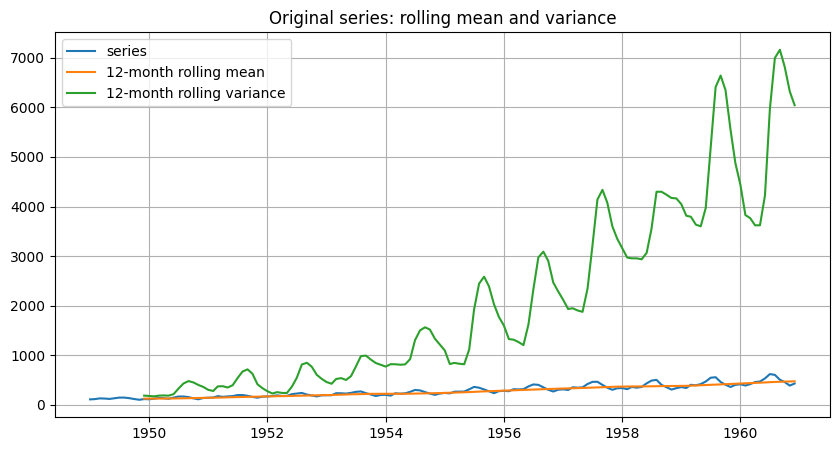

Stationarity tests for original passenger series
ADF p-value  : 0.9919  (small p-value suggests stationarity)
KPSS p-value : 0.0100  (small p-value suggests non-stationarity)


C:\Users\PRIYANKA\AppData\Local\Temp\ipykernel_3532\369780873.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


In [11]:
def run_stationarity_tests(x, name="series"):
    x = pd.Series(x).dropna()
    print(f"Stationarity tests for {name}")
    adf_stat, adf_p, *_ = adfuller(x)
    print(f"ADF p-value  : {adf_p:.4f}  (small p-value suggests stationarity)")
    try:
        kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
        print(f"KPSS p-value : {kpss_p:.4f}  (small p-value suggests non-stationarity)")
    except Exception as e:
        print("KPSS test could not be computed:", e)

def plot_rolling_diagnostics(x, title):
    x = pd.Series(x).dropna()
    fig, ax = plt.subplots()
    ax.plot(x, label="series")
    ax.plot(x.rolling(12).mean(), label="12-month rolling mean")
    ax.plot(x.rolling(12).var(), label="12-month rolling variance")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_rolling_diagnostics(series, "Original series: rolling mean and variance")
run_stationarity_tests(series, "original passenger series")

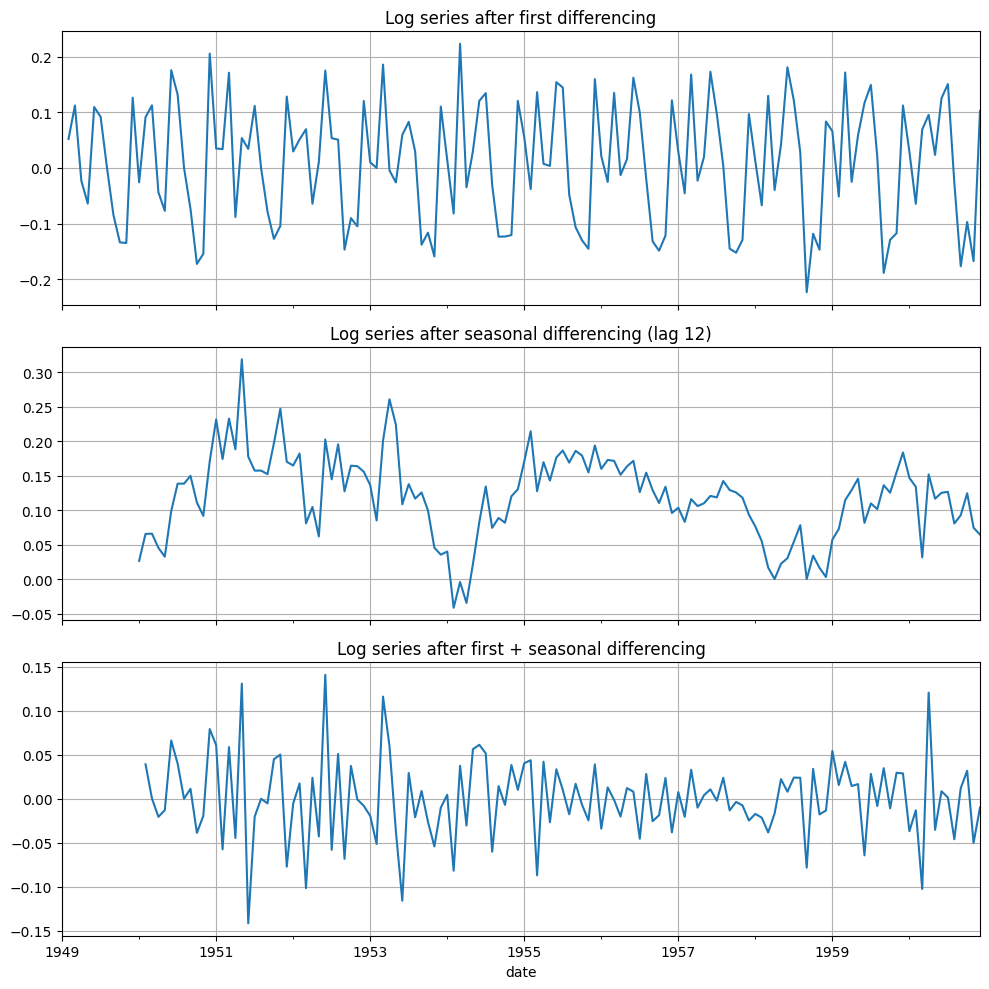

Stationarity tests for log first difference
ADF p-value  : 0.0711  (small p-value suggests stationarity)
KPSS p-value : 0.1000  (small p-value suggests non-stationarity)
Stationarity tests for log seasonal difference
ADF p-value  : 0.0724  (small p-value suggests stationarity)
KPSS p-value : 0.1000  (small p-value suggests non-stationarity)
Stationarity tests for log first + seasonal difference
ADF p-value  : 0.0002  (small p-value suggests stationarity)
KPSS p-value : 0.1000  (small p-value suggests non-stationarity)


C:\Users\PRIYANKA\AppData\Local\Temp\ipykernel_3532\369780873.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
C:\Users\PRIYANKA\AppData\Local\Temp\ipykernel_3532\369780873.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
C:\Users\PRIYANKA\AppData\Local\Temp\ipykernel_3532\369780873.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


In [12]:
log_series = np.log(series)
first_diff = log_series.diff()
seasonal_diff = log_series.diff(12)
first_and_seasonal_diff = log_series.diff().diff(12)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
first_diff.plot(ax=axes[0], title="Log series after first differencing")
seasonal_diff.plot(ax=axes[1], title="Log series after seasonal differencing (lag 12)")
first_and_seasonal_diff.plot(ax=axes[2], title="Log series after first + seasonal differencing")
plt.tight_layout()
plt.show()

run_stationarity_tests(first_diff, "log first difference")
run_stationarity_tests(seasonal_diff, "log seasonal difference")
run_stationarity_tests(first_and_seasonal_diff, "log first + seasonal difference")

## Autocorrelation and partial autocorrelation

**Autocorrelation (ACF)** measures how strongly a series is correlated with lagged versions of itself. **Partial autocorrelation (PACF)** measures the direct relationship with a lag after accounting for shorter lags.

ACF/PACF plots help reason about ARIMA terms, but they should be interpreted cautiously. In small seasonal datasets, several plausible parameter choices may behave similarly.

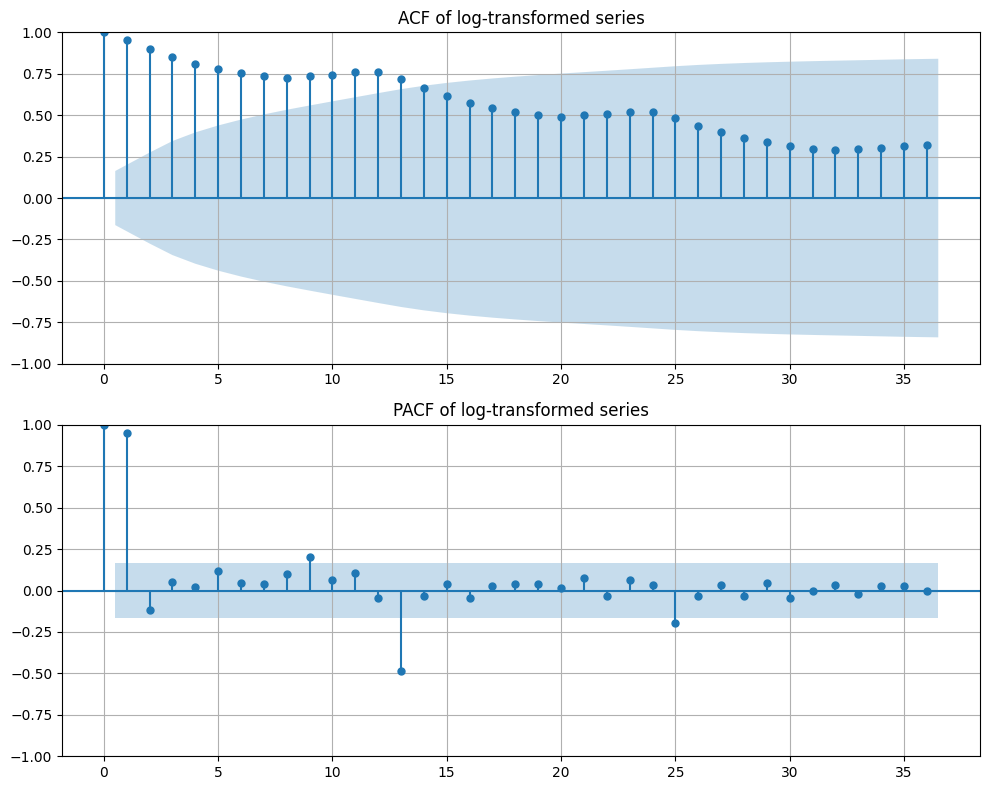

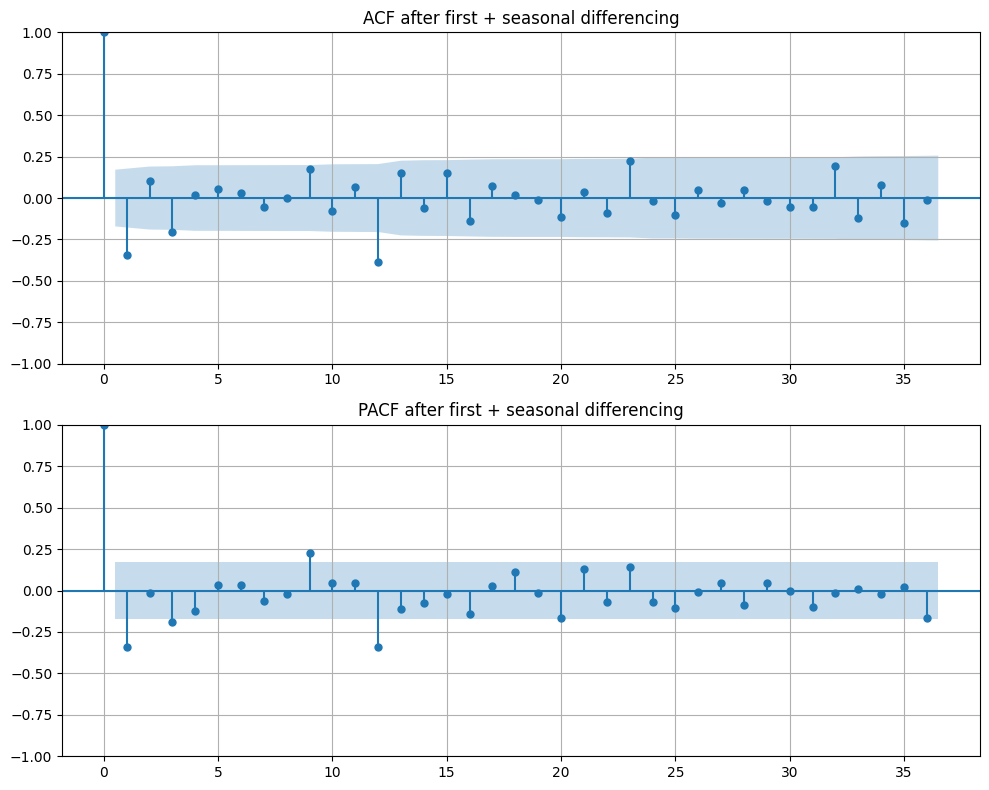

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(log_series.dropna(), lags=36, ax=axes[0])
axes[0].set_title("ACF of log-transformed series")
plot_pacf(log_series.dropna(), lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF of log-transformed series")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(first_and_seasonal_diff.dropna(), lags=36, ax=axes[0])
axes[0].set_title("ACF after first + seasonal differencing")
plot_pacf(first_and_seasonal_diff.dropna(), lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF after first + seasonal differencing")
plt.tight_layout()
plt.show()

## Time-based train-test split

Forecasting should not use a random train-test split. Random splitting allows future-like observations to appear in the training set and destroys temporal dependence. A proper split uses earlier observations for training and later observations for testing.

Here, the last 24 months are reserved for testing so that we can evaluate two full seasonal cycles.

Training period: 1949-01-01 to 1958-12-01
Testing period : 1959-01-01 to 1960-12-01


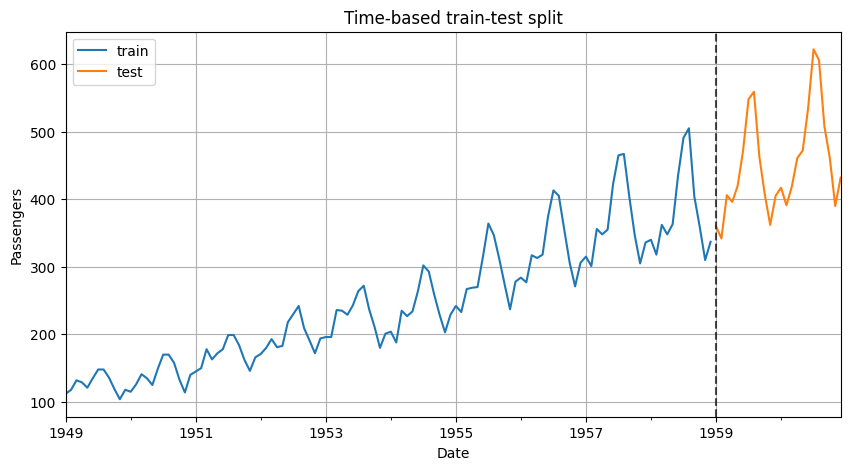

In [14]:
test_size = 24
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("Training period:", train.index.min().date(), "to", train.index.max().date())
print("Testing period :", test.index.min().date(), "to", test.index.max().date())

ax = train.plot(label="train")
test.plot(ax=ax, label="test")
ax.axvline(test.index.min(), color="black", linestyle="--", alpha=0.7)
ax.set_title("Time-based train-test split")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
plt.show()

## Evaluation metrics

Different forecasting metrics emphasize different kinds of error.

- **MAE** is easy to interpret because it uses the same unit as the target.
- **RMSE** penalizes large errors more strongly.
- **MAPE** reports percentage error but becomes unstable when actual values are near zero.
- **sMAPE** is a symmetric percentage alternative, though it also has limitations.

A single metric rarely tells the whole story, so model comparison should consider several metrics and plots.

In [15]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def evaluate_forecast(y_true, y_pred, model_name, params="", notes=""):
    y_pred = pd.Series(np.asarray(y_pred), index=y_true.index)
    return {
        "Model": model_name,
        "Key parameters": params,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "Notes": notes
    }

def plot_forecast(train, test, pred, title):
    pred = pd.Series(np.asarray(pred), index=test.index)
    fig, ax = plt.subplots(figsize=(11, 5))
    train.plot(ax=ax, label="train")
    test.plot(ax=ax, label="actual test", marker="o")
    pred.plot(ax=ax, label="forecast", marker="o")
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Passengers")
    ax.legend()
    plt.show()

results = []

### Reader note on metric interpretation

The metric table should be read together with the plots. MAE and RMSE stay in the original unit of the target, so they are easy to explain. RMSE becomes larger when a model occasionally makes large mistakes. MAPE and sMAPE are scale-free, but percentage metrics can exaggerate errors when actual values are small. In this dataset the target is positive and not close to zero, so percentage metrics are usable, but RMSE/MAE should still be treated as the primary error scale.


## Baseline 1: naive forecast

The naive forecast predicts the future using the most recently observed value. It is extremely simple, but it is an important sanity check. If a complex model cannot beat the naive forecast, the complexity is not justified.

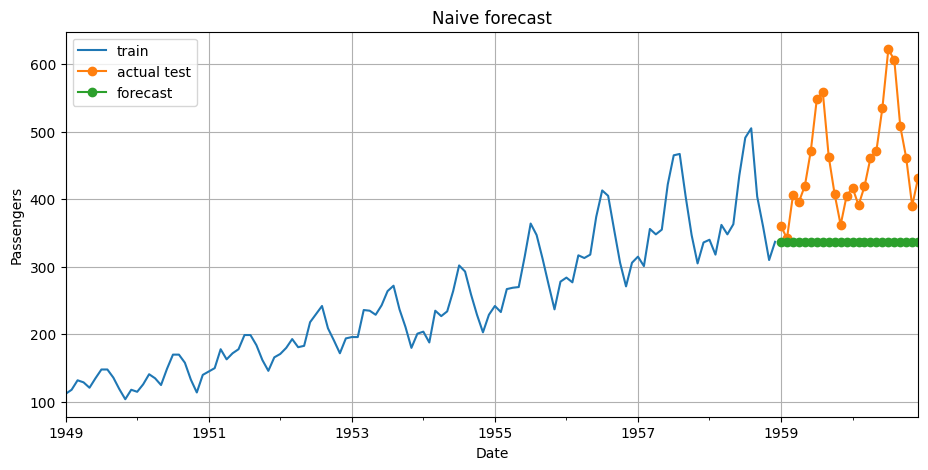

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,Naive,last observed value,115.25,137.329,23.577,27.751,Simple non-seasonal baseline


In [16]:
naive_pred = np.repeat(train.iloc[-1], len(test))
results.append(evaluate_forecast(test, naive_pred, "Naive", "last observed value", "Simple non-seasonal baseline"))
plot_forecast(train, test, naive_pred, "Naive forecast")
pd.DataFrame(results).round(3)

## Baseline 2: seasonal naive forecast

For monthly seasonal data, a strong baseline is to predict a month using the value from the same month in the previous year. This baseline is often hard to beat when seasonality dominates the signal.

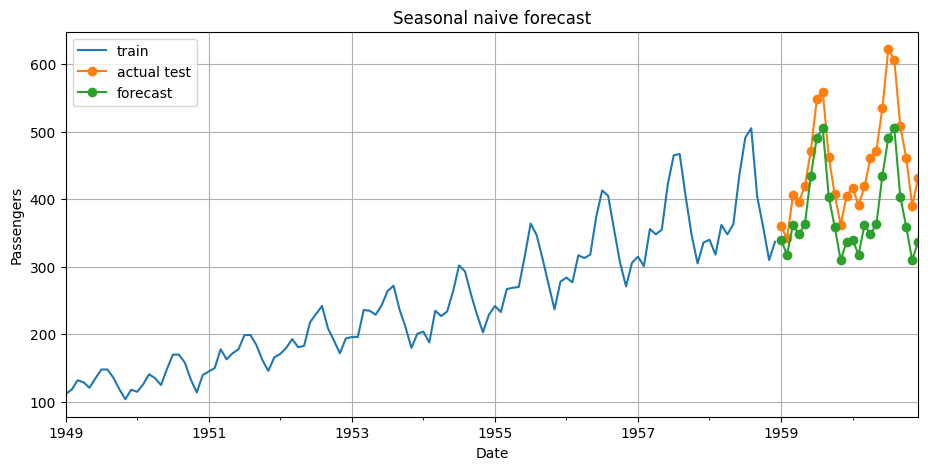

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,Naive,last observed value,115.25,137.329,23.577,27.751,Simple non-seasonal baseline
1,Seasonal naive,seasonal_period=12,71.25,76.995,15.523,17.013,Uses same month from previous year recursively


In [17]:
def recursive_seasonal_naive(history, steps, seasonal_period=12):
    history = list(history)
    preds = []
    for _ in range(steps):
        pred = history[-seasonal_period]
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

seasonal_naive_pred = recursive_seasonal_naive(train.values, len(test), seasonal_period=12)
results.append(evaluate_forecast(test, seasonal_naive_pred, "Seasonal naive", "seasonal_period=12", "Uses same month from previous year recursively"))
plot_forecast(train, test, seasonal_naive_pred, "Seasonal naive forecast")
pd.DataFrame(results).round(3)

## Moving average forecast

A moving average smooths recent observations. Small windows react quickly but are noisy; large windows are smoother but may lag behind trend changes. For forecasting, the window must be computed only from past observations and previous forecasts, never from future actual values.

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,Moving average,window=3,120.544,141.790,24.781,29.293,Recursive moving-average forecast
1,Moving average,window=6,90.428,113.191,18.292,20.812,Recursive moving-average forecast
2,Moving average,window=12,72.677,99.156,14.350,16.182,Recursive moving-average forecast


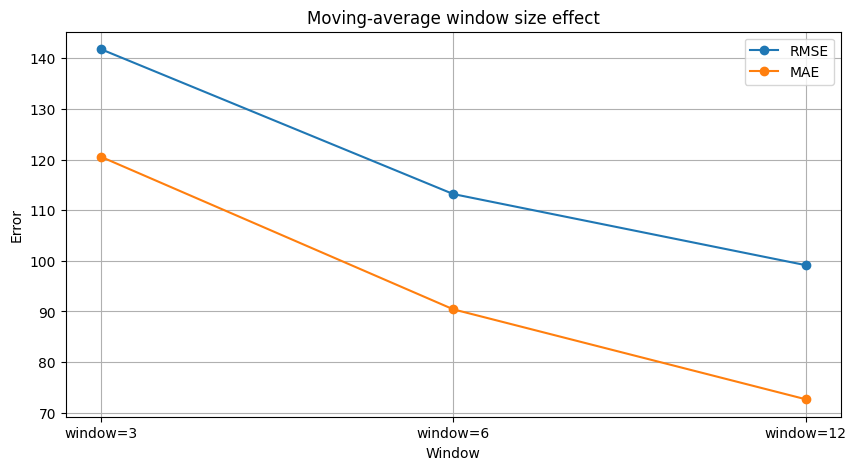

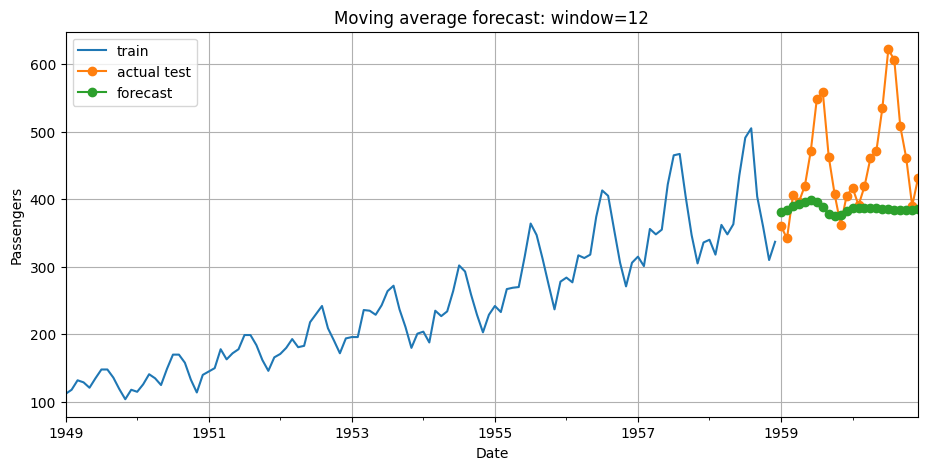

In [18]:
def recursive_moving_average(history, steps, window):
    history = list(history)
    preds = []
    for _ in range(steps):
        pred = np.mean(history[-window:])
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

ma_records = []
for window in [3, 6, 12]:
    pred = recursive_moving_average(train.values, len(test), window)
    row = evaluate_forecast(test, pred, "Moving average", f"window={window}", "Recursive moving-average forecast")
    ma_records.append(row)
    results.append(row)

ma_df = pd.DataFrame(ma_records)
display(ma_df.round(3))

fig, ax = plt.subplots()
ax.plot(ma_df["Key parameters"], ma_df["RMSE"], marker="o", label="RMSE")
ax.plot(ma_df["Key parameters"], ma_df["MAE"], marker="o", label="MAE")
ax.set_title("Moving-average window size effect")
ax.set_xlabel("Window")
ax.set_ylabel("Error")
ax.legend()
plt.show()

best_ma = min(ma_records, key=lambda r: r["RMSE"])
best_window = int(best_ma["Key parameters"].split("=")[1])
best_ma_pred = recursive_moving_average(train.values, len(test), best_window)
plot_forecast(train, test, best_ma_pred, f"Moving average forecast: window={best_window}")

## Simple Exponential Smoothing

Simple Exponential Smoothing assigns larger weight to recent observations and smaller weight to older observations. It is suitable when there is no strong trend or seasonality. Here we still test it because it provides a useful comparison before adding trend and seasonality.

The smoothing parameter **alpha** controls reactivity. A small alpha produces a smoother forecast that reacts slowly. A large alpha reacts more quickly but may follow noise.

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,Simple Exponential Smoothing,alpha=0.1,83.564,108.630,16.667,18.993,No explicit trend or seasonality
1,Simple Exponential Smoothing,alpha=0.3,89.041,114.044,17.808,20.446,No explicit trend or seasonality
2,Simple Exponential Smoothing,alpha=0.5,106.813,130.073,21.685,25.339,No explicit trend or seasonality
3,Simple Exponential Smoothing,alpha=0.8,118.177,139.795,24.241,28.601,No explicit trend or seasonality


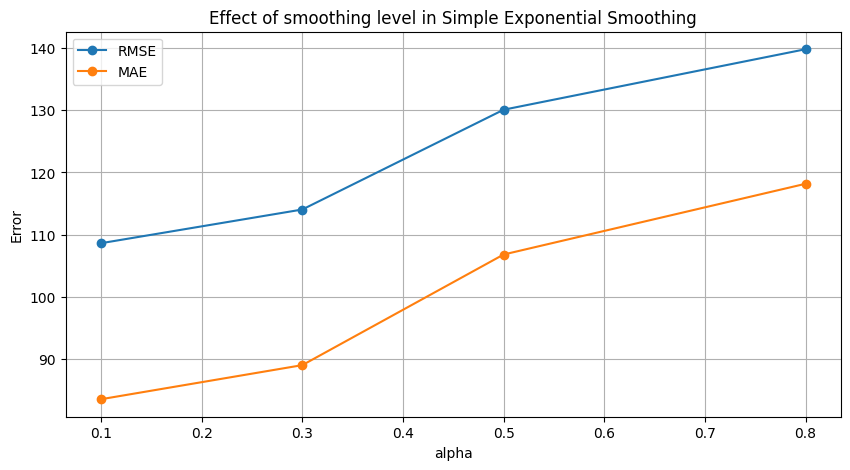

In [19]:
ses_records = []
for alpha in [0.1, 0.3, 0.5, 0.8]:
    model = SimpleExpSmoothing(train, initialization_method="estimated").fit(smoothing_level=alpha, optimized=False)
    pred = model.forecast(len(test))
    row = evaluate_forecast(test, pred, "Simple Exponential Smoothing", f"alpha={alpha}", "No explicit trend or seasonality")
    ses_records.append(row)
    results.append(row)

ses_df = pd.DataFrame(ses_records)
display(ses_df.round(3))

fig, ax = plt.subplots()
ax.plot([0.1, 0.3, 0.5, 0.8], ses_df["RMSE"], marker="o", label="RMSE")
ax.plot([0.1, 0.3, 0.5, 0.8], ses_df["MAE"], marker="o", label="MAE")
ax.set_title("Effect of smoothing level in Simple Exponential Smoothing")
ax.set_xlabel("alpha")
ax.set_ylabel("Error")
ax.legend()
plt.show()

## Holt's linear trend method

Holt's method extends exponential smoothing by estimating both the current level and the trend. It is useful when the series has a systematic upward or downward movement. It still does not explicitly model repeated seasonal effects, so it may struggle when annual seasonality is strong.

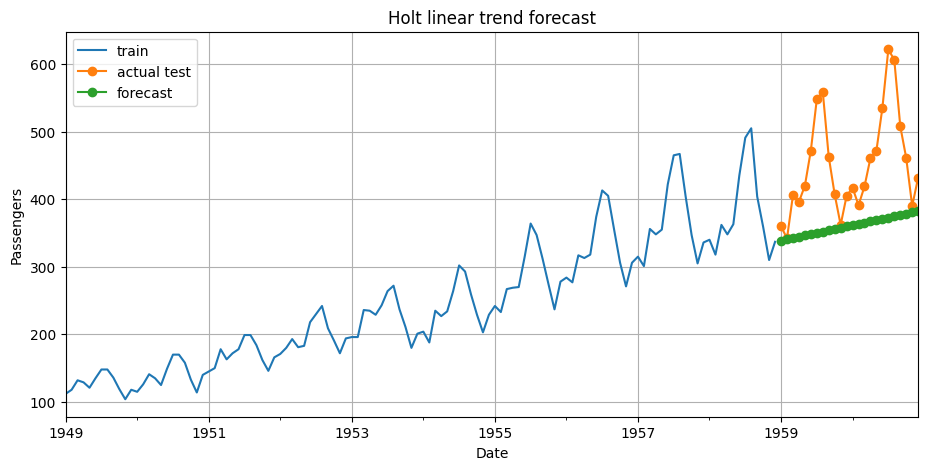

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
4,Moving average,window=12,72.677,99.156,14.350,16.182,Recursive moving-average forecast
5,Simple Exponential Smoothing,alpha=0.1,83.564,108.630,16.667,18.993,No explicit trend or seasonality
6,Simple Exponential Smoothing,alpha=0.3,89.041,114.044,17.808,20.446,No explicit trend or seasonality
7,Simple Exponential Smoothing,alpha=0.5,106.813,130.073,21.685,25.339,No explicit trend or seasonality
8,Simple Exponential Smoothing,alpha=0.8,118.177,139.795,24.241,28.601,No explicit trend or seasonality
9,Holt linear trend,optimized level/trend,91.615,115.703,18.408,21.198,Trend but no seasonality


In [20]:
holt_model = Holt(train, initialization_method="estimated").fit(optimized=True)
holt_pred = holt_model.forecast(len(test))
results.append(evaluate_forecast(test, holt_pred, "Holt linear trend", "optimized level/trend", "Trend but no seasonality"))

plot_forecast(train, test, holt_pred, "Holt linear trend forecast")
pd.DataFrame(results).tail(6).round(3)

## Holt-Winters seasonal method

Holt-Winters extends exponential smoothing to level, trend, and seasonality. With monthly data, the seasonal period is 12. Additive seasonality assumes a roughly constant seasonal swing; multiplicative seasonality assumes the swing grows with the series level.

Because passenger demand is positive and the seasonal amplitude tends to grow with the level, multiplicative seasonality is a plausible candidate. The results should still be compared empirically.

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,Holt-Winters additive,"trend=add, seasonal=additive, damped_trend=False",31.080,35.762,6.637,6.922,Level + trend + seasonality
1,Holt-Winters multiplicative,"trend=add, seasonal=multiplicative, damped_tre...",28.977,32.489,6.391,6.655,Level + trend + seasonality
2,Holt-Winters additive,"trend=add, seasonal=additive, damped_trend=True",41.205,46.624,8.856,9.361,Level + trend + seasonality
3,Holt-Winters multiplicative,"trend=add, seasonal=multiplicative, damped_tre...",36.515,40.997,8.012,8.430,Level + trend + seasonality


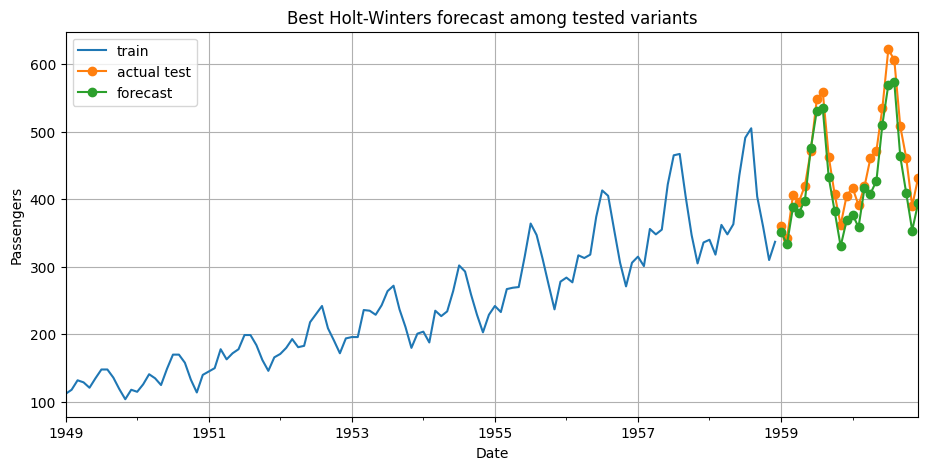

In [21]:
hw_configs = [
    ("additive", False),
    ("multiplicative", False),
    ("additive", True),
    ("multiplicative", True),
]

hw_records = []
hw_predictions = {}
for seasonal, damped in hw_configs:
    try:
        model = ExponentialSmoothing(
            train,
            trend="add",
            damped_trend=damped,
            seasonal=seasonal,
            seasonal_periods=12,
            initialization_method="estimated"
        ).fit(optimized=True)
        pred = model.forecast(len(test))
        name = f"Holt-Winters {seasonal}"
        params = f"trend=add, seasonal={seasonal}, damped_trend={damped}"
        row = evaluate_forecast(test, pred, name, params, "Level + trend + seasonality")
        hw_records.append(row)
        results.append(row)
        hw_predictions[params] = pred
    except Exception as e:
        print("Skipped", seasonal, damped, "because:", e)

hw_df = pd.DataFrame(hw_records)
display(hw_df.round(3))

best_hw = min(hw_records, key=lambda r: r["RMSE"])
best_hw_pred = hw_predictions[best_hw["Key parameters"]]
plot_forecast(train, test, best_hw_pred, "Best Holt-Winters forecast among tested variants")

## ARIMA

ARIMA(p, d, q) has three components:

- **AR(p):** uses previous values of the series.
- **I(d):** applies differencing to reduce non-stationarity.
- **MA(q):** uses previous forecast errors.

ARIMA is not just a black box: each term corresponds to a type of temporal structure. The small set of candidate orders below is guided by differencing and ACF/PACF inspection rather than brute-force search.

In [22]:
arima_orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1)]
arima_records = []
arima_predictions = {}

for order in arima_orders:
    try:
        model = ARIMA(np.log(train), order=order).fit()
        log_pred = model.forecast(len(test))
        pred = np.exp(log_pred)
        row = evaluate_forecast(test, pred, "ARIMA", f"order={order} on log(series)", "Non-seasonal ARIMA")
        arima_records.append(row)
        results.append(row)
        arima_predictions[str(order)] = pred
    except Exception as e:
        print("Skipped ARIMA", order, "because:", e)

arima_df = pd.DataFrame(arima_records)
display(arima_df.round(3))

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,ARIMA,"order=(1, 1, 0) on log(series)",108.823,131.842,22.131,25.909,Non-seasonal ARIMA
1,ARIMA,"order=(0, 1, 1) on log(series)",105.081,128.531,21.302,24.851,Non-seasonal ARIMA
2,ARIMA,"order=(1, 1, 1) on log(series)",101.865,126.155,20.558,23.949,Non-seasonal ARIMA
3,ARIMA,"order=(2, 1, 1) on log(series)",81.871,107.845,16.264,18.543,Non-seasonal ARIMA


## SARIMA

SARIMA extends ARIMA by adding seasonal autoregressive, seasonal differencing, and seasonal moving-average terms.

The notation is:

\[
SARIMA(p,d,q)(P,D,Q,s)
\]

where `s` is the seasonal period. For monthly data with annual seasonality, `s = 12`. Seasonal differencing (`D=1`) is often useful when the series repeats annually.

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,SARIMA,"order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),...",42.658,46.394,9.219,9.723,Seasonal ARIMA
1,SARIMA,"order=(1, 1, 0), seasonal_order=(1, 1, 0, 12),...",50.465,55.207,10.960,11.699,Seasonal ARIMA
2,SARIMA,"order=(0, 1, 1), seasonal_order=(1, 1, 1, 12),...",44.582,49.129,9.669,10.248,Seasonal ARIMA


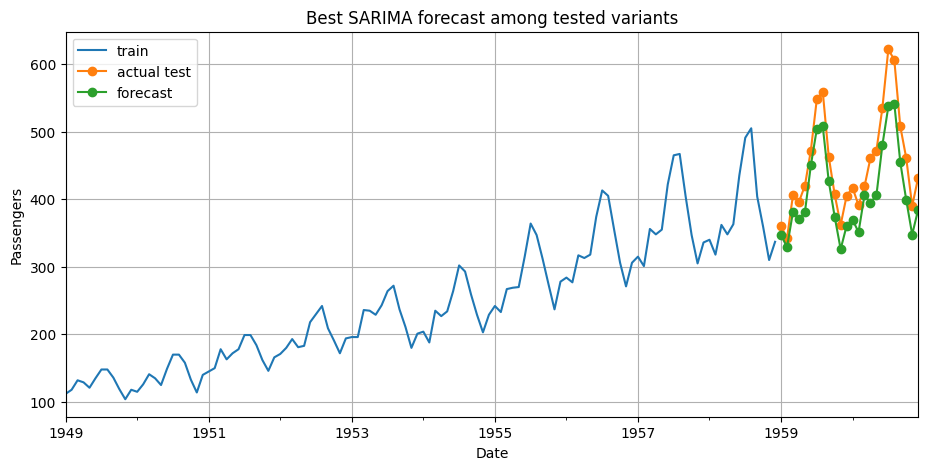

In [23]:
sarima_configs = [
    ((1, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 0, 12)),
    ((0, 1, 1), (1, 1, 1, 12)),
]

sarima_records = []
sarima_predictions = {}

for order, seasonal_order in sarima_configs:
    try:
        model = SARIMAX(
            np.log(train),
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        log_pred = model.forecast(len(test))
        pred = np.exp(log_pred)
        params = f"order={order}, seasonal_order={seasonal_order}, log(series)"
        row = evaluate_forecast(test, pred, "SARIMA", params, "Seasonal ARIMA")
        sarima_records.append(row)
        results.append(row)
        sarima_predictions[params] = pred
    except Exception as e:
        print("Skipped SARIMA", order, seasonal_order, "because:", e)

sarima_df = pd.DataFrame(sarima_records)
display(sarima_df.round(3))

if sarima_records:
    best_sarima = min(sarima_records, key=lambda r: r["RMSE"])
    plot_forecast(train, test, sarima_predictions[best_sarima["Key parameters"]], "Best SARIMA forecast among tested variants")

## Machine learning with lag features

A time series can be converted into supervised learning by creating features from the past. For example, `lag_1` is the value from the previous month, and `lag_12` is the value from the same month in the previous year.

The critical rule is that features must be constructed without using future values. Rolling means below are shifted before rolling so the current target does not leak into its own predictors.

In [24]:
def make_lag_features(y):
    df = pd.DataFrame({"y": y})
    for lag in [1, 2, 3, 6, 12]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    for window in [3, 6, 12]:
        df[f"rolling_mean_{window}"] = df["y"].shift(1).rolling(window).mean()
    month = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)
    return df.dropna()

supervised = make_lag_features(series)
train_sup = supervised.loc[supervised.index <= train.index.max()]
test_sup = supervised.loc[supervised.index >= test.index.min()]

X_train, y_train = train_sup.drop(columns="y"), train_sup["y"]
X_test, y_test = test_sup.drop(columns="y"), test_sup["y"]

print(X_train.shape, X_test.shape)
display(X_train.head())

(108, 10) (24, 10)


,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,month_sin,month_cos
date,,,,,,,,,,
1950-01-01,118.0,104.0,119.0,148.0,112.0,113.666667,128.833333,126.666667,0.500000,8.660254e-01
1950-02-01,115.0,118.0,104.0,148.0,118.0,112.333333,123.333333,126.916667,0.866025,5.000000e-01
1950-03-01,126.0,115.0,118.0,136.0,132.0,119.666667,119.666667,127.583333,1.000000,6.123234e-17
1950-04-01,141.0,126.0,115.0,119.0,129.0,127.333333,120.500000,128.333333,0.866025,-5.000000e-01
1950-05-01,135.0,141.0,126.0,104.0,121.0,134.000000,123.166667,128.833333,0.500000,-8.660254e-01


,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
21,ML lag model: Ridge,"{'memory': None, 'steps': [('scaler', Standard...",15.702,19.441,3.436,3.496,Lag and rolling features; no future values used
22,ML lag model: Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",41.924,59.612,8.382,9.000,Lag and rolling features; no future values used
23,ML lag model: HistGradientBoosting,"{'categorical_features': None, 'early_stopping...",57.062,78.403,11.226,12.363,Lag and rolling features; no future values used


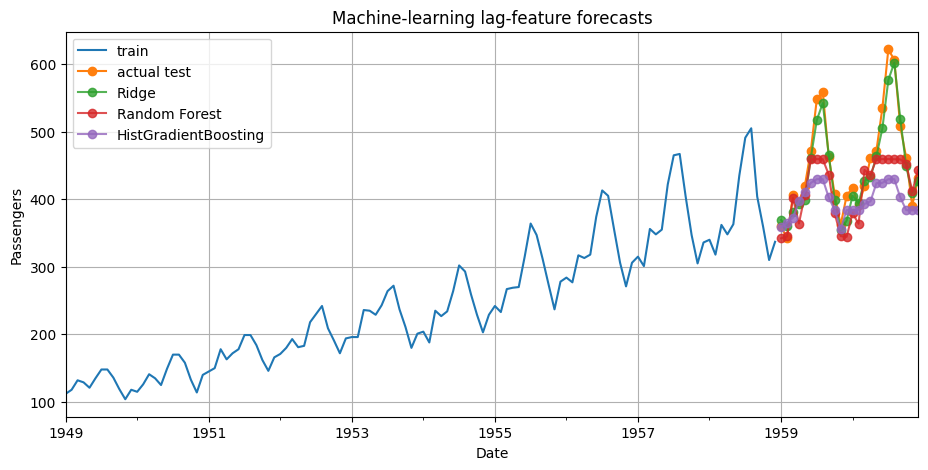

In [25]:
ml_models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE
    )
}

ml_predictions = {}
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    ml_predictions[name] = pd.Series(pred, index=y_test.index)
    notes = "Lag and rolling features; no future values used"
    params = str(model.get_params())[:120] + "..."
    results.append(evaluate_forecast(y_test, pred, f"ML lag model: {name}", params, notes))

display(pd.DataFrame(results).tail(3).round(3))

fig, ax = plt.subplots(figsize=(11, 5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="actual test", marker="o")
for name, pred in ml_predictions.items():
    pred.plot(ax=ax, label=name, marker="o", alpha=0.8)
ax.set_title("Machine-learning lag-feature forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
plt.show()

### Selected hyperparameter effects for tree-based lag models

A deeper tree can capture more nonlinear interactions, but it may overfit a small time series. More trees stabilize a random forest but increase computation. Larger `min_samples_leaf` smooths the decision rules and can reduce overfitting.

,n_estimators,max_depth,min_samples_leaf,train_RMSE,test_RMSE,test_MAE
0,100,3.0,3,13.364,58.783,40.538
1,300,5.0,3,10.353,59.612,41.924
2,300,NaN,1,6.236,49.064,35.988
3,300,5.0,8,19.212,80.020,52.279


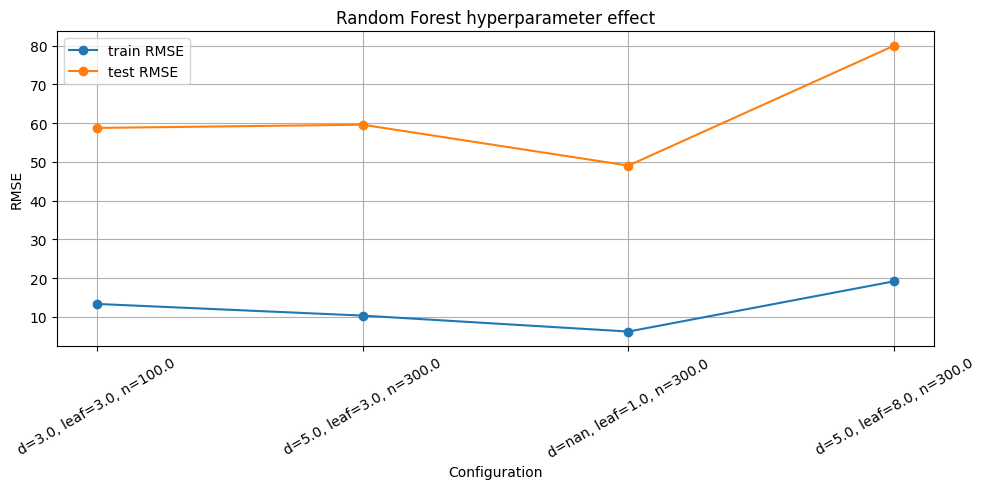

In [26]:
rf_records = []
rf_settings = [
    {"n_estimators": 100, "max_depth": 3, "min_samples_leaf": 3},
    {"n_estimators": 300, "max_depth": 5, "min_samples_leaf": 3},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 5, "min_samples_leaf": 8},
]

for params in rf_settings:
    rf = RandomForestRegressor(random_state=RANDOM_STATE, **params)
    rf.fit(X_train, y_train)
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    rf_records.append({
        **params,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "test_MAE": mean_absolute_error(y_test, test_pred)
    })

rf_effect_df = pd.DataFrame(rf_records)
display(rf_effect_df.round(3))

fig, ax = plt.subplots()
labels = [f"d={r['max_depth']}, leaf={r['min_samples_leaf']}, n={r['n_estimators']}" for _, r in rf_effect_df.iterrows()]
ax.plot(labels, rf_effect_df["train_RMSE"], marker="o", label="train RMSE")
ax.plot(labels, rf_effect_df["test_RMSE"], marker="o", label="test RMSE")
ax.set_title("Random Forest hyperparameter effect")
ax.set_xlabel("Configuration")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## Rolling-origin validation

A single train-test split can be unstable, especially with small time series. Rolling-origin validation evaluates models across several historical cutoffs. At each cutoff, the model trains on the past and forecasts the next horizon.

This gives a better view of whether a model performs consistently or only looks good for one particular split.

,fold,cutoff,model,MAE,RMSE,sMAPE
0,1,1954-12-01,seasonal_naive,45.083,45.921,17.228
1,1,1954-12-01,holt_winters_multiplicative,19.451,23.219,6.774
2,2,1955-12-01,seasonal_naive,44.250,45.184,14.488
3,2,1955-12-01,holt_winters_multiplicative,9.997,12.921,2.880
4,3,1956-12-01,seasonal_naive,40.167,41.475,11.381
5,3,1956-12-01,holt_winters_multiplicative,14.562,18.776,3.763
6,4,1957-12-01,seasonal_naive,12.583,17.012,3.220
7,4,1957-12-01,holt_winters_multiplicative,15.556,18.225,4.108
8,5,1958-12-01,seasonal_naive,47.333,49.254,11.761
9,5,1958-12-01,holt_winters_multiplicative,20.216,22.388,4.938


,MAE,RMSE,sMAPE
model,,,
holt_winters_multiplicative,15.014,18.556,4.104
seasonal_naive,39.542,41.592,11.442


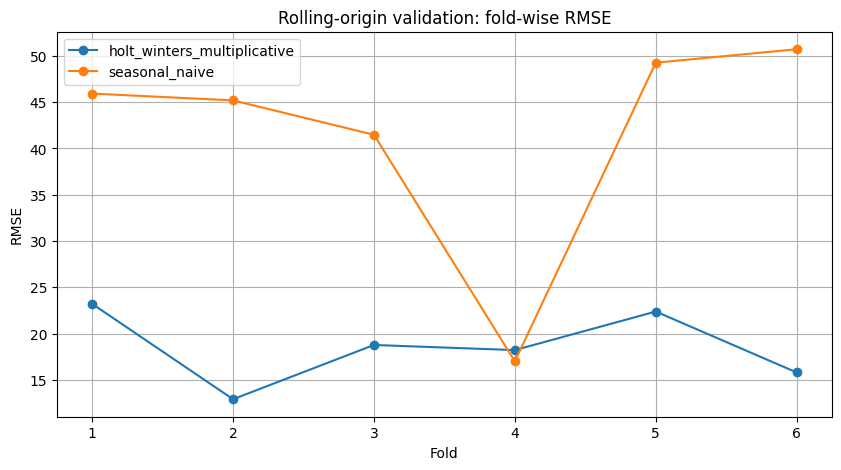

In [27]:
def rolling_origin_splits(y, min_train_size=72, horizon=12, step=12):
    splits = []
    n = len(y)
    start = min_train_size
    while start + horizon <= n:
        train_part = y.iloc[:start]
        test_part = y.iloc[start:start+horizon]
        splits.append((train_part, test_part))
        start += step
    return splits

def forecast_seasonal_naive(train_part, horizon):
    return recursive_seasonal_naive(train_part.values, horizon, 12)

def forecast_holt_winters(train_part, horizon):
    model = ExponentialSmoothing(
        train_part,
        trend="add",
        seasonal="multiplicative",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit(optimized=True)
    return model.forecast(horizon)

rolling_records = []
for fold, (tr, te) in enumerate(rolling_origin_splits(series, min_train_size=72, horizon=12, step=12), start=1):
    candidates = {
        "seasonal_naive": forecast_seasonal_naive(tr, len(te)),
        "holt_winters_multiplicative": forecast_holt_winters(tr, len(te)),
    }
    for name, pred in candidates.items():
        rolling_records.append({
            "fold": fold,
            "cutoff": tr.index.max(),
            "model": name,
            "MAE": mean_absolute_error(te, pred),
            "RMSE": np.sqrt(mean_squared_error(te, pred)),
            "sMAPE": smape(te, pred)
        })

rolling_df = pd.DataFrame(rolling_records)
display(rolling_df.round(3))
display(rolling_df.groupby("model")[["MAE", "RMSE", "sMAPE"]].mean().round(3))

fig, ax = plt.subplots()
for model_name, group in rolling_df.groupby("model"):
    ax.plot(group["fold"], group["RMSE"], marker="o", label=model_name)
ax.set_title("Rolling-origin validation: fold-wise RMSE")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE")
ax.legend()
plt.show()

## Final model comparison

The table below compares the models tested in this notebook. After execution, compare whether SARIMA or Holt-Winters meaningfully improves over seasonal naive. If the improvement is small, the simpler model may be preferable because it is easier to explain and maintain.

In [28]:
comparison_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df.round(3))

,Model,Key parameters,MAE,RMSE,MAPE,sMAPE,Notes
0,ML lag model: Ridge,"{'memory': None, 'steps': [('scaler', Standard...",15.702,19.441,3.436,3.496,Lag and rolling features; no future values used
1,Holt-Winters multiplicative,"trend=add, seasonal=multiplicative, damped_tre...",28.977,32.489,6.391,6.655,Level + trend + seasonality
2,Holt-Winters additive,"trend=add, seasonal=additive, damped_trend=False",31.080,35.762,6.637,6.922,Level + trend + seasonality
3,Holt-Winters multiplicative,"trend=add, seasonal=multiplicative, damped_tre...",36.515,40.997,8.012,8.430,Level + trend + seasonality
4,SARIMA,"order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),...",42.658,46.394,9.219,9.723,Seasonal ARIMA
5,Holt-Winters additive,"trend=add, seasonal=additive, damped_trend=True",41.205,46.624,8.856,9.361,Level + trend + seasonality
6,SARIMA,"order=(0, 1, 1), seasonal_order=(1, 1, 1, 12),...",44.582,49.129,9.669,10.248,Seasonal ARIMA
7,SARIMA,"order=(1, 1, 0), seasonal_order=(1, 1, 0, 12),...",50.465,55.207,10.960,11.699,Seasonal ARIMA
8,ML lag model: Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",41.924,59.612,8.382,9.000,Lag and rolling features; no future values used
9,Seasonal naive,seasonal_period=12,71.250,76.995,15.523,17.013,Uses same month from previous year recursively


## where do forecast errors occur?

A single average error can hide systematic behavior. Two models may have similar RMSE, but one may fail mainly at long horizons while another may fail during specific seasonal peaks. The next section breaks absolute error by forecast horizon and calendar month for representative models.

After execution, check whether errors increase with horizon and whether high-demand months have larger misses. If a model performs well on average but fails at seasonal peaks, the residual plots and month-wise error table will reveal it more clearly than the final metric table alone.


,mean,median,max
model,,,
Best Holt-Winters,28.977,31.132,52.838
Best SARIMA,42.658,43.200,84.628
Best moving average,72.677,44.508,237.164
Holt,91.615,68.437,249.076
ML lag RF,41.924,25.832,162.606
Naive,115.250,89.000,285.000
Seasonal naive,71.250,63.500,131.000


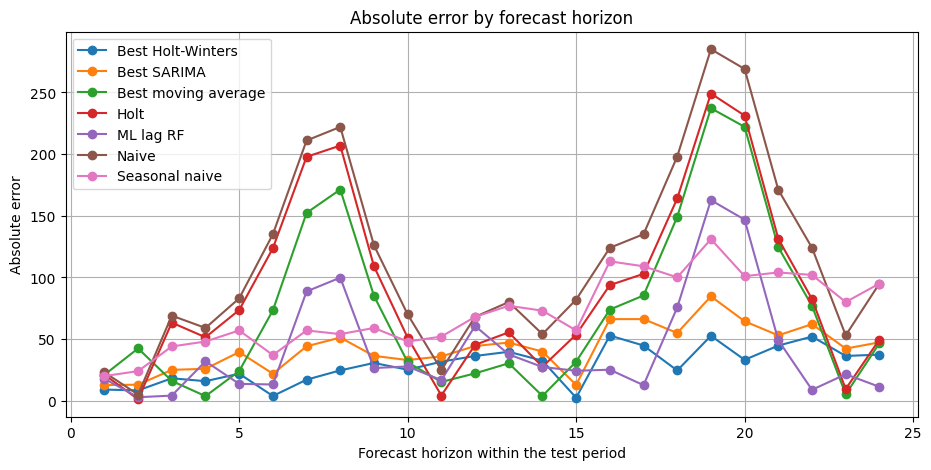

model,Best Holt-Winters,Best SARIMA,Best moving average,Holt,ML lag RF,Naive,Seasonal naive
month,,,,,,,
Jan,24.362,29.925,25.683,38.265,27.673,51.5,48.5
Feb,20.421,26.442,23.156,14.374,15.095,29.5,48.5
Mar,10.310,18.932,23.860,58.483,14.220,75.5,50.5
Apr,34.349,46.019,38.805,72.592,28.551,91.5,80.5
May,33.328,52.820,54.675,88.202,13.134,109.0,83.0
Jun,14.175,38.400,111.189,143.811,44.388,166.5,68.5
Jul,34.856,64.385,194.735,223.420,125.606,248.0,94.0
Aug,28.887,57.818,196.658,219.029,123.309,245.5,77.5
Sep,37.654,44.668,104.703,120.139,37.783,148.5,81.5


In [29]:
# Build a compact prediction bank for comparable error diagnostics.
error_prediction_bank = {
    "Naive": pd.Series(naive_pred, index=test.index),
    "Seasonal naive": pd.Series(seasonal_naive_pred, index=test.index),
    "Best moving average": pd.Series(best_ma_pred, index=test.index),
    "Holt": pd.Series(holt_pred, index=test.index),
    "Best Holt-Winters": pd.Series(best_hw_pred, index=test.index),
}
if sarima_records:
    error_prediction_bank["Best SARIMA"] = pd.Series(sarima_predictions[best_sarima["Key parameters"]], index=test.index)
if "Random Forest" in ml_predictions:
    error_prediction_bank["ML lag RF"] = pd.Series(ml_predictions["Random Forest"], index=test.index)

error_rows = []
for model_name, pred in error_prediction_bank.items():
    aligned_pred = pd.Series(pred, index=test.index)
    abs_err = (test - aligned_pred).abs()
    for h, (date, err) in enumerate(abs_err.items(), start=1):
        error_rows.append({
            "model": model_name,
            "date": date,
            "horizon": h,
            "month": date.strftime("%b"),
            "absolute_error": err,
            "signed_error": test.loc[date] - aligned_pred.loc[date]
        })

error_by_period = pd.DataFrame(error_rows)
display(error_by_period.groupby("model")["absolute_error"].agg(["mean", "median", "max"]).round(3))

fig, ax = plt.subplots(figsize=(11, 5))
for model_name, group in error_by_period.groupby("model"):
    ax.plot(group["horizon"], group["absolute_error"], marker="o", label=model_name)
ax.set_title("Absolute error by forecast horizon")
ax.set_xlabel("Forecast horizon within the test period")
ax.set_ylabel("Absolute error")
ax.legend()
plt.show()

month_error = error_by_period.pivot_table(index="month", columns="model", values="absolute_error", aggfunc="mean")
# Preserve calendar order where all months are present.
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_error = month_error.reindex([m for m in month_order if m in month_error.index])
display(month_error.round(3))


## Residual analysis

A good forecasting model should leave residuals that look like noise. If residuals still contain trend, seasonality, or autocorrelation, the model has missed structure. Residual analysis is therefore not just a diagnostic afterthought; it tells us what remains unexplained.

Top models by RMSE: ['ML lag model: Ridge', 'Holt-Winters multiplicative', 'Holt-Winters additive']
Best listed model: ML lag model: Ridge | {'memory': None, 'steps': [('scaler', StandardScaler()), ('model', Ridge(random_state=42))], 'verbose': False, 'scaler':...


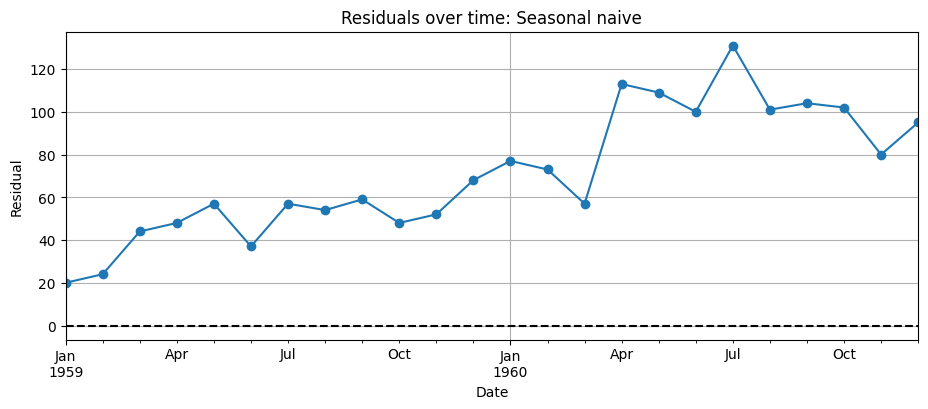

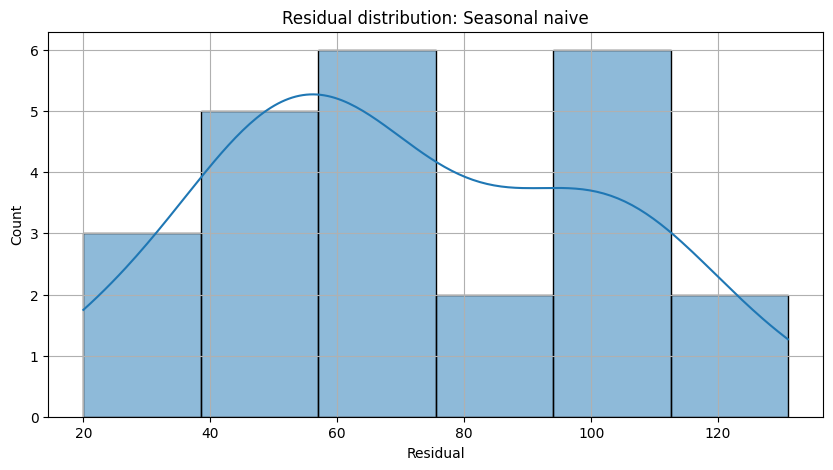

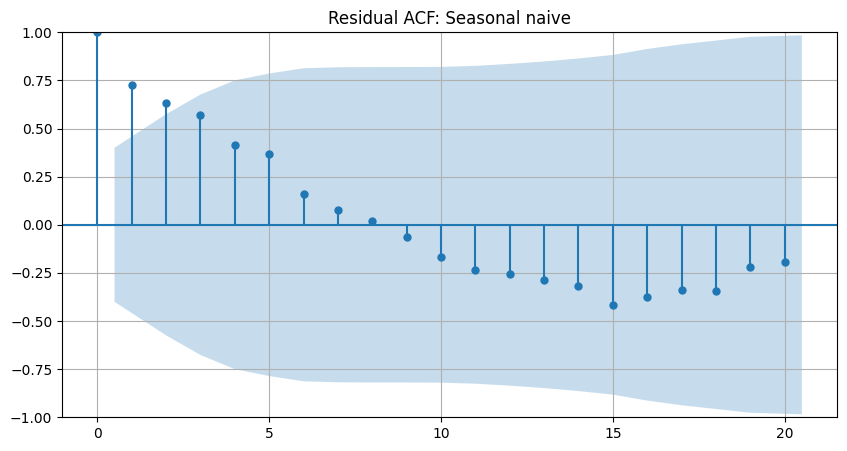

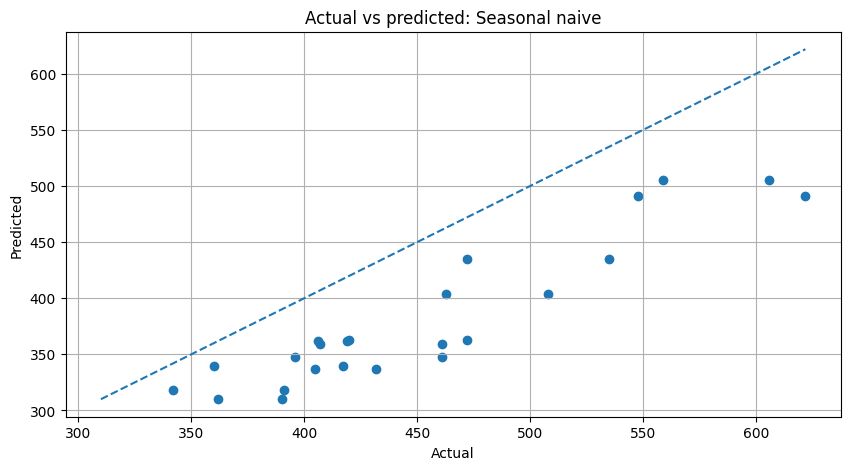

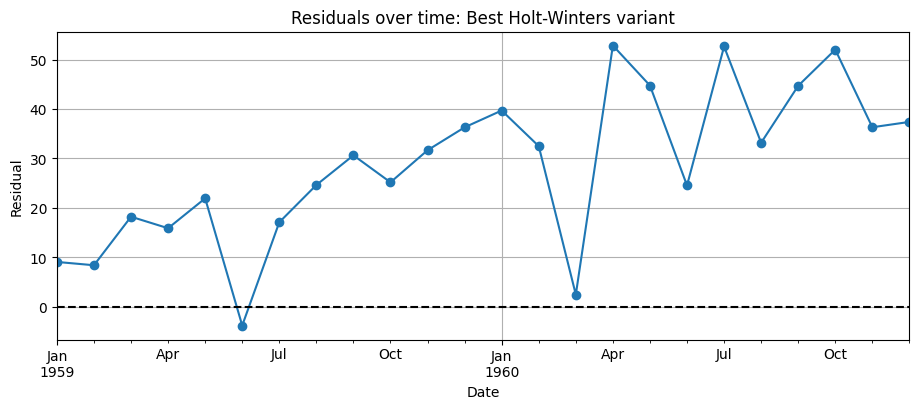

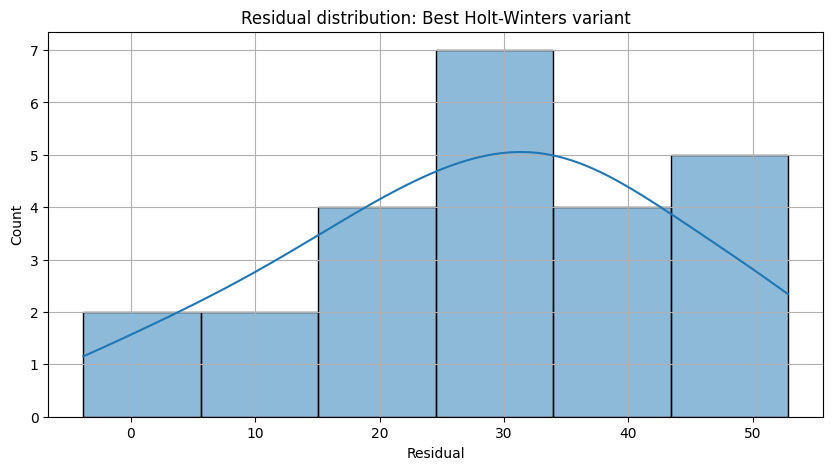

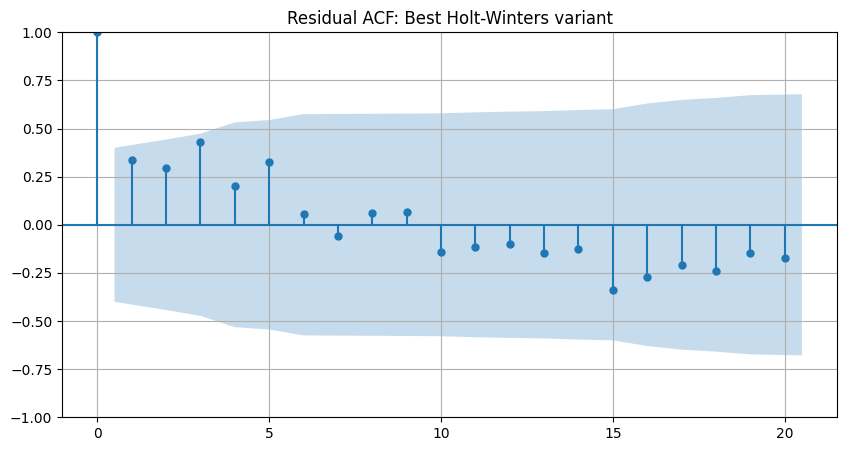

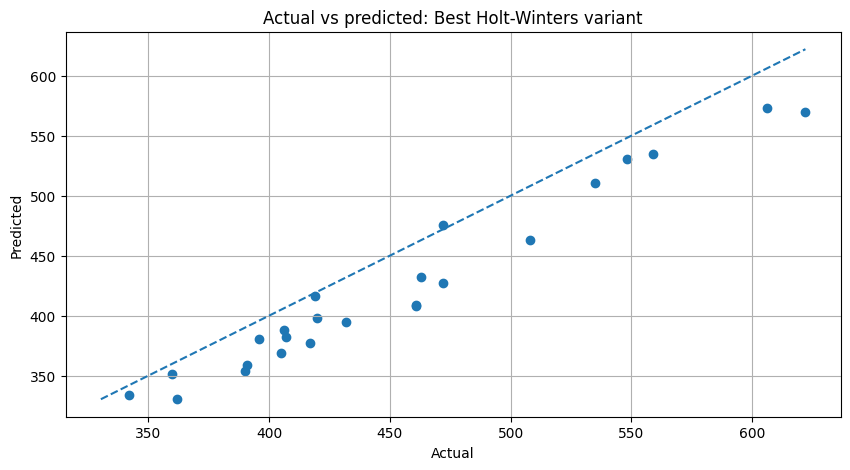

In [30]:
def residual_diagnostics(y_true, y_pred, title):
    y_pred = pd.Series(np.asarray(y_pred), index=y_true.index)
    resid = y_true - y_pred

    fig, ax = plt.subplots(figsize=(11, 4))
    resid.plot(ax=ax, marker="o")
    ax.axhline(0, color="black", linestyle="--")
    ax.set_title(f"Residuals over time: {title}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual")
    plt.show()

    fig, ax = plt.subplots()
    sns.histplot(resid, kde=True, ax=ax)
    ax.set_title(f"Residual distribution: {title}")
    ax.set_xlabel("Residual")
    plt.show()

    fig, ax = plt.subplots()
    plot_acf(resid, lags=min(20, len(resid)-1), ax=ax)
    ax.set_title(f"Residual ACF: {title}")
    plt.show()

    fig, ax = plt.subplots()
    ax.scatter(y_true, y_pred)
    min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    ax.set_title(f"Actual vs predicted: {title}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    plt.show()

# Diagnose the top few models from the comparison table.
top_models = comparison_df.head(3)["Model"].tolist()
print("Top models by RMSE:", top_models)

# Manually map available predictions for common candidates.
prediction_bank = {
    "Naive": pd.Series(naive_pred, index=test.index),
    "Seasonal naive": pd.Series(seasonal_naive_pred, index=test.index),
    "Holt linear trend": pd.Series(holt_pred, index=test.index),
}
for params, pred in hw_predictions.items():
    prediction_bank[f"Holt-Winters {params}"] = pd.Series(pred, index=test.index)
for params, pred in sarima_predictions.items():
    prediction_bank[f"SARIMA {params}"] = pd.Series(pred, index=test.index)
for name, pred in ml_predictions.items():
    prediction_bank[f"ML lag model: {name}"] = pred

# Use the best row, then select a matching stored prediction when possible.
best_row = comparison_df.iloc[0]
print("Best listed model:", best_row["Model"], "|", best_row["Key parameters"])

# For simplicity, run diagnostics on seasonal naive and best Holt-Winters, which are always interpretable baselines.
residual_diagnostics(test, seasonal_naive_pred, "Seasonal naive")
residual_diagnostics(test, best_hw_pred, "Best Holt-Winters variant")

### residual checks: bias and remaining autocorrelation

Residual plots are the most intuitive diagnostic, but two compact numerical checks make the discussion sharper. Mean error indicates forecast bias: positive values mean the model tends to underpredict, while negative values mean it tends to overpredict. The Ljung-Box test checks whether residual autocorrelation remains across several lags. A low p-value suggests that the model has left time-dependent structure unexplained.

These tests should not be used mechanically. With a short test set, they are only supporting evidence. They are most useful when they agree with the residual ACF and the actual-versus-predicted plot.


,model,mean_error_bias,mean_absolute_error,residual_std,ljung_box_pvalue
4,Best Holt-Winters,28.6582,28.9772,15.6333,0.0142
6,ML lag RF,36.9341,41.9239,47.7980,0.0016
5,Best SARIMA,42.6581,42.6581,18.6315,0.0184
1,Seasonal naive,71.2500,71.2500,29.8099,0.0000
2,Best moving average,66.1248,72.6775,75.4766,0.0000
3,Holt,91.6155,91.6155,72.1874,0.0000
0,Naive,115.2500,115.2500,76.2834,0.0000


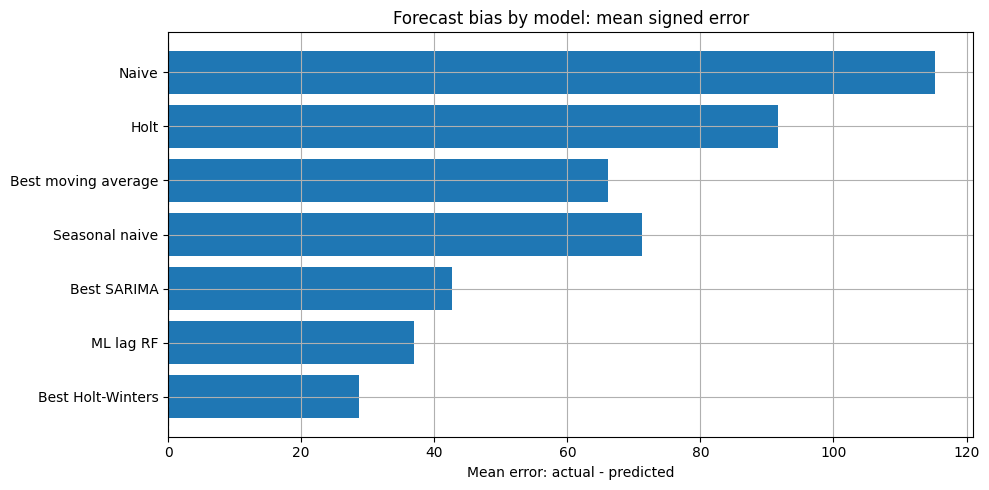

In [31]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residual_summary_rows = []
for model_name, pred in error_prediction_bank.items():
    pred = pd.Series(pred, index=test.index)
    resid = test - pred
    try:
        lb = acorr_ljungbox(resid, lags=[min(6, len(resid)-2)], return_df=True)
        lb_pvalue = lb["lb_pvalue"].iloc[0]
    except Exception:
        lb_pvalue = np.nan
    residual_summary_rows.append({
        "model": model_name,
        "mean_error_bias": resid.mean(),
        "mean_absolute_error": resid.abs().mean(),
        "residual_std": resid.std(),
        "ljung_box_pvalue": lb_pvalue
    })

residual_summary = pd.DataFrame(residual_summary_rows).sort_values("mean_absolute_error")
display(residual_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(residual_summary["model"], residual_summary["mean_error_bias"])
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Forecast bias by model: mean signed error")
ax.set_xlabel("Mean error: actual - predicted")
plt.tight_layout()
plt.show()


## Interpretation and practical lessons

Read the final results in four passes rather than as a single leaderboard.

First, compare every model against the naive and seasonal-naive baselines. A forecasting method is not automatically useful just because it is mathematically sophisticated. If Holt-Winters or SARIMA improves only slightly over seasonal naive, the simpler seasonal baseline may still be the more robust explanation of the series.

Second, compare the error curves by horizon. A model that is accurate for the first few months but deteriorates quickly may be useful for short-term planning but weak for annual planning. Conversely, a model with slightly larger short-horizon errors may still be attractive if its errors stay stable across the full test window.

Third, inspect residuals. Good residuals should fluctuate around zero without a visible trend or seasonal rhythm. If residual ACF remains high at seasonal lags, the model has not fully captured the repeating monthly structure. If residuals are mostly positive or mostly negative, the model is biased.

Finally, judge complexity. Machine-learning lag models can be powerful, but on a small univariate monthly dataset they may not always beat a strong seasonal method. Classical statistical models often remain highly competitive because the main structure is trend plus seasonality rather than a large set of external predictors.


## Limitations

This notebook is intentionally educational and univariate. It teaches the mechanics of forecasting, but several practical issues remain.

- The dataset is small, so model ranking can be sensitive to the chosen test window.
- Only the historical target is used. Real demand forecasting often needs external regressors such as holidays, prices, weather, promotions, population, or economic conditions.
- The examples focus mainly on point forecasts. In real planning, prediction intervals are often as important as the expected forecast.
- MAPE and sMAPE are useful here because the target is positive, but percentage errors can be misleading when actual values are near zero.
- SARIMA and Holt-Winters assume that historical seasonal structure remains informative. Structural breaks, policy changes, pandemics, or market changes can invalidate that assumption.
- The machine-learning lag models use engineered lag and rolling features. They do not automatically understand time unless the features are constructed carefully without future leakage.


## What we learned

- Time order must be respected in forecasting.
- Simple baselines are essential.
- Trend and seasonality guide model choice.
- Stationarity matters for ARIMA-style models.
- Exponential smoothing and SARIMA provide interpretable statistical forecasting approaches.
- Machine learning requires careful lag construction to avoid leakage.
- Rolling-origin validation gives a stronger view of forecasting stability than a single split.

## Possible extensions

Useful extensions include external regressors, Prophet-style models, prediction intervals, probabilistic forecasting, hierarchical forecasting, multivariate forecasting, temporal convolutional networks, LSTM-based forecasting, and time-series anomaly detection.